  [FML] step     0 | -ELBO 1.8033 | beta=0.499  tau_c=1.003 | wait 0
  [FML] step   200 | -ELBO 0.6511 | beta=0.225  tau_c=1.912 | wait 0
  [FML] step   400 | -ELBO -0.0487 | beta=0.104  tau_c=2.681 | wait 0
  [FML] step   600 | -ELBO -0.7020 | beta=0.059  tau_c=3.028 | wait 0
  [FML] step   800 | -ELBO -1.2682 | beta=0.040  tau_c=2.262 | wait 0
  [FML] step  1000 | -ELBO -1.7810 | beta=0.023  tau_c=1.663 | wait 8
  [FML] step  1200 | -ELBO -2.2978 | beta=0.016  tau_c=1.520 | wait 0
  [FML] step  1400 | -ELBO -2.6372 | beta=0.014  tau_c=1.488 | wait 0
  [FML] step  1600 | -ELBO -2.8202 | beta=0.014  tau_c=1.487 | wait 0
  [FML] step  1800 | -ELBO -2.9088 | beta=0.014  tau_c=1.487 | wait 2
  [FML] step  2000 | -ELBO -2.9566 | beta=0.014  tau_c=1.487 | wait 0
  [FML] step  2200 | -ELBO -2.9811 | beta=0.014  tau_c=1.487 | wait 0
  [FML] step  2400 | -ELBO -2.9915 | beta=0.014  tau_c=1.487 | wait 5
  [FML] step  2600 | -ELBO -2.9980 | beta=0.014  tau_c=1.487 | wait 1
  [FML] step  2800 | -

PosixPath('micelles_maxwell_fit')

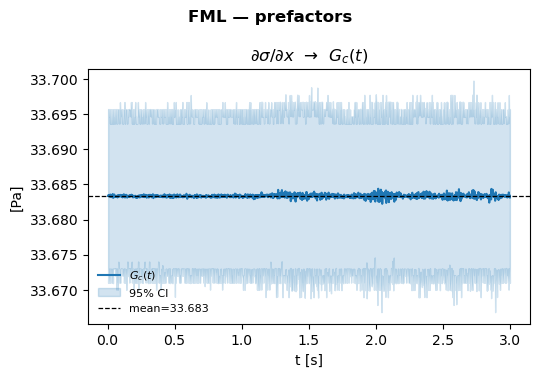

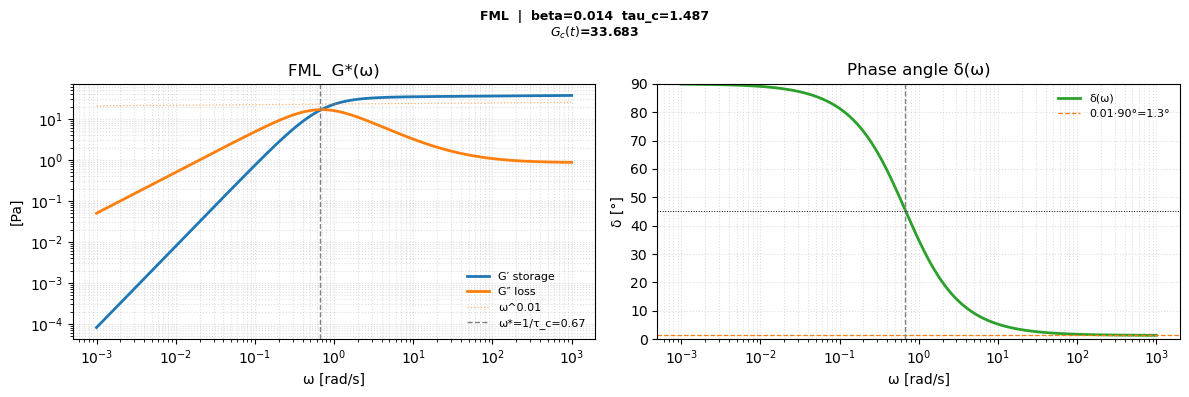

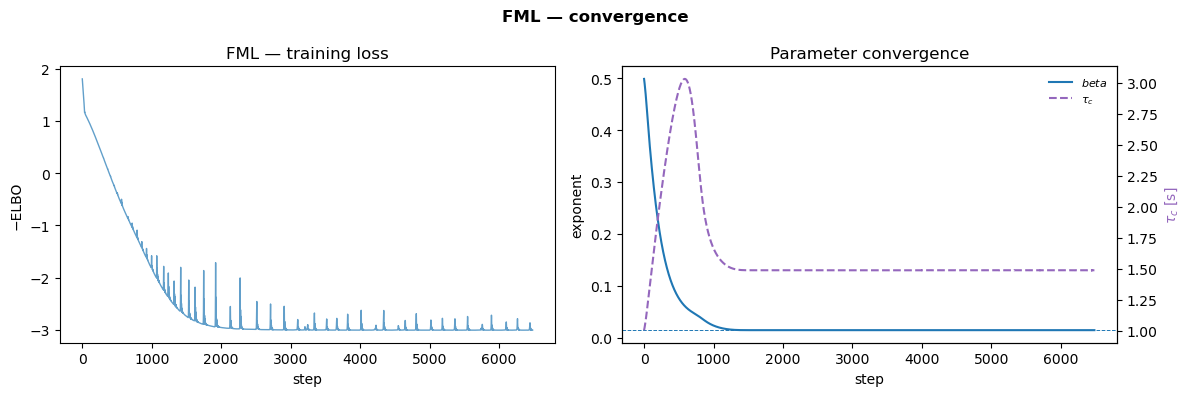

In [1]:
from rheogp import SPGP
from rheogp.utils import compare_models
import pandas as pd
import numpy as np
import time
from pathlib import Path

file_path = Path.cwd().parent / "demos" / "data" / "micelles_chirps_short_0.xlsx"
df = pd.read_excel(file_path)

t      = df.iloc[:, 0].values.astype(np.float32)
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32)

model = SPGP(model="FML", kernel="linear",          # NEW default: two-phase RBF→linear
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000).fit(t, strain, stress)

t0 = time.perf_counter()
model.fit(t, strain, stress)
print(f"Training time: {time.perf_counter()-t0:.1f} s")

print(model.summary())                     # now includes AIC/AICc/BIC + parameter breakdown

sigma_pred, sigma_std = model.predict(strain, return_std=True)

model.plot_prefactors()
model.plot_Gstar()
model.plot_convergence()

# NEW: everything as plain numpy, for your own paper figures
res = model.results()
res.t, res.prediction, res.prediction_std   # fit ± σ
res.features, res.feature_names             # physical features x_i(t)
res.sensitivities["Gc"]["mean"]             # time-resolved prefactor + CI bands
res.omega, res.Gp, res.Gdp                  # model G', G''
res.metrics["aic"], res.metrics["bic"]      # information criteria
res.save("micelles_maxwell_fit")            # → .npz + .json, reload with FitResult.load()

cross-chirp  R² = 0.9976   RMSE = 0.154 Pa


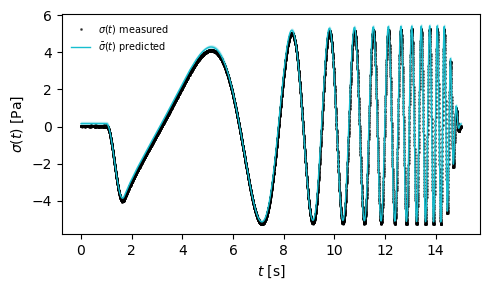

In [2]:
# ---- load the second chirp ----
file_2 = Path.cwd().parent / "demos" / "data" / "micelles_chirp_-90.xlsx"
df2 = pd.read_excel(file_2)
t2      = df2.iloc[:, 0].values.astype(np.float32)
strain2 = df2.iloc[:, 1].values.astype(np.float32)
stress2 = df2.iloc[:, 2].values.astype(np.float32)

# ---- predict with the ALREADY-trained model (no retraining) ----
sigma2, sigma2_std = model.predict(strain2, time=t2, return_std=True)

# ---- how well does it generalize? ----
r2 = 1 - np.sum((stress2 - sigma2)**2) / np.sum((stress2 - stress2.mean())**2)
rmse = float(np.sqrt(np.mean((stress2 - sigma2)**2)))
print(f"cross-chirp  R² = {r2:.4f}   RMSE = {rmse:.4g} Pa")

import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(t2, stress2, "o", ms=1, color="k", alpha=.6, label=r"$\sigma(t)$ measured")
plt.plot(t2, sigma2, "-", lw=1, color="tab:cyan", label=r"$\bar{\sigma}(t)$ predicted")
plt.fill_between(t2, sigma2-2*sigma2_std, sigma2+2*sigma2_std,
                 color="tab:cyan", alpha=.25)
plt.xlabel("$t$ [s]"); plt.ylabel(r"$\sigma(t)$ [Pa]")
plt.legend(frameon=False, fontsize=7); plt.tight_layout(); plt.show()

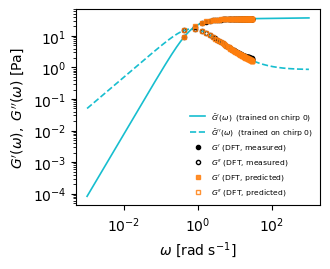

median |G'  predicted/analytic - 1| = 0.0004
median |G'' predicted/analytic - 1| = 0.0046
median |G'  measured /analytic - 1| = 0.0033


In [3]:
import matplotlib.pyplot as plt

def gstar_dft(strain, stress, dt, w_lo, w_hi):
    """G*(w) = FFT(stress) / FFT(strain), restricted to the excited band."""
    n = len(strain)
    w = 2*np.pi*np.fft.rfftfreq(n, d=dt)
    G = np.fft.rfft(stress) / np.fft.rfft(strain)
    k = (w >= w_lo) & (w <= w_hi) & (w > 0)
    return w[k], G.real[k], G.imag[k]

dt2 = float(np.mean(np.diff(t2)))
W_LO, W_HI = 0.3, 30.0          # excited band of the chirp-90 record

# route 1: DFT of the MEASURED stress of chirp 90
w_m, Gp_m, Gdp_m = gstar_dft(strain2, stress2, dt2, W_LO, W_HI)
# route 2: DFT of the PREDICTED stress of chirp 90
w_p, Gp_p, Gdp_p = gstar_dft(strain2, sigma2,  dt2, W_LO, W_HI)
# route 3: analytical FML with the parameters trained on chirp 0
res = model.results()

fig, ax = plt.subplots(figsize=(3.4, 2.8))

# analytic curve from the TRAINING fit
mw = res.omega > 0
ax.plot(res.omega[mw], res.Gp[mw],  "-",  color="tab:cyan", lw=1.2,
        label=r"$\bar{G}'(\omega)$  (trained on chirp 0)")
ax.plot(res.omega[mw], res.Gdp[mw], "--", color="tab:cyan", lw=1.2,
        label=r"$\bar{G}''(\omega)$  (trained on chirp 0)")

# DFT of the measured chirp 90
ax.plot(w_m, Gp_m,  "o", color="k", ms=3, label=r"$G'$ (DFT, measured)")
ax.plot(w_m, Gdp_m, "o", color="k", ms=3, mfc="none", label=r"$G''$ (DFT, measured)")

# DFT of the GP prediction for chirp 90
ax.plot(w_p, Gp_p,  "s", color="tab:orange", ms=3, alpha=.85,
        label=r"$G'$ (DFT, predicted)")
ax.plot(w_p, Gdp_p, "s", color="tab:orange", ms=3, mfc="none", alpha=.85,
        label=r"$G''$ (DFT, predicted)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\omega$ [rad s$^{-1}$]")
ax.set_ylabel(r"$G'(\omega),\ G''(\omega)$ [Pa]")
ax.legend(frameon=False, fontsize=5.5, ncol=1)
fig.tight_layout(); plt.show()

# quantitative agreement
Gp_an  = np.interp(w_p, res.omega, res.Gp)
Gdp_an = np.interp(w_p, res.omega, res.Gdp)
print(f"median |G'  predicted/analytic - 1| = {np.median(abs(Gp_p/Gp_an-1)):.4f}")
print(f"median |G'' predicted/analytic - 1| = {np.median(abs(Gdp_p/Gdp_an-1)):.4f}")
print(f"median |G'  measured /analytic - 1| = {np.median(abs(Gp_m/Gp_an-1)):.4f}")

/appl/scibuilder-mamba/aalto-rhel9/prod/software/scicomp-python-env/2025.2/b4b5f8e/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


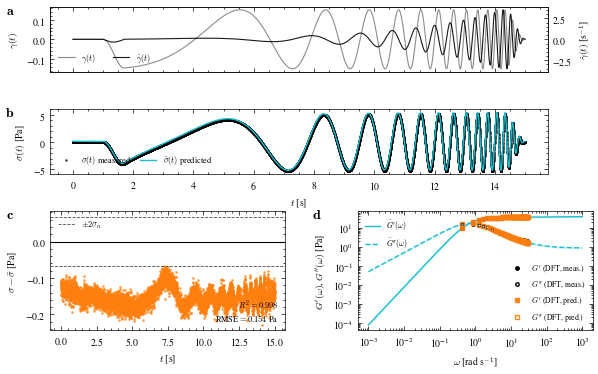

time domain : R2 = 0.9976,  RMSE = 0.154 Pa,  inferred noise sd = 0.03405 Pa
residual sd = 0.02424 Pa  (ratio to noise sd: 0.71)
freq domain : median |G'  pred/analytic - 1| = 0.0004
              median |G'  meas/analytic - 1| = 0.0033


In [4]:
"""
Cross-chirp prediction figure
=============================
A GP trained on one chirp (chirp 0) is evaluated on a *different*
chirp of the same material (chirp 90) that it never saw during
training. Nothing is refitted.

Panels:
  a — new chirp input: strain gamma(t) (left y) + strain rate (right y)
  b — measured stress vs GP prediction with 2-sigma band
  c — residuals (measured - predicted), with the inferred noise level
  e — G', G'' : analytic model (trained on chirp 0, with band)
                vs DFT of measured chirp 90
                vs DFT of predicted chirp 90

Assumes the following already exist in the session:
    model                      the SPGP fitted on chirp 0
    t2, strain2, stress2       the chirp-90 record
Run the PREDICTION block below if you have not already.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import scienceplots

plt.style.use(['science', 'nature', 'bright', 'no-latex'])
plt.rcParams.update({
    'text.usetex': False,          # render with mathtext; no TeX installation needed
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'axes.grid': False,
})
plt.rcParams['figure.constrained_layout.use'] = True

cmap = plt.get_cmap('tab10')
color1 = cmap(0)     # blue
color2 = cmap(1)     # orange
color9 = cmap(9)     # cyan

# ---------------------------------------------------------------
# PREDICTION (skip if already computed)
# ---------------------------------------------------------------
# sigma2, sigma2_std = model.predict(strain2, time=t2, return_std=True)

res = model.results()

# ---------------------------------------------------------------
# Frequency-domain estimator
# ---------------------------------------------------------------
W_LO, W_HI = 0.3, 30.0          # excited band of the chirp-90 record

def gstar_dft(strain, stress, dt, w_lo, w_hi):
    """G*(w) = FFT(stress) / FFT(strain) restricted to the excited band."""
    n = len(strain)
    w = 2 * np.pi * np.fft.rfftfreq(n, d=dt)
    G = np.fft.rfft(stress) / np.fft.rfft(strain)
    k = (w >= w_lo) & (w <= w_hi) & (w > 0)
    return w[k], G.real[k], G.imag[k]

dt2 = float(np.mean(np.diff(t2)))
w_m, Gp_m, Gdp_m = gstar_dft(strain2, stress2, dt2, W_LO, W_HI)  # measured
w_p, Gp_p, Gdp_p = gstar_dft(strain2, sigma2,  dt2, W_LO, W_HI)  # predicted

# analytic model curves + prefactor-propagated band (trained on chirp 0)
mw   = res.omega > 0
ow   = res.omega[mw]
Gp_a, Gdp_a = res.Gp[mw], res.Gdp[mw]
pf   = res.sensitivities[list(res.sensitivities)[0]]     # "Gc" for FML
c_m  = pf["scalar_mean"]
rel  = 0.5 * (pf["scalar_upper"] - pf["scalar_lower"]) / c_m   # relative half-width
Gp_lo,  Gp_hi  = Gp_a  * (1 - rel), Gp_a  * (1 + rel)
Gdp_lo, Gdp_hi = Gdp_a * (1 - rel), Gdp_a * (1 + rel)

# ---------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------
fig = plt.figure(figsize=(7, 4.2), constrained_layout=True)
gs  = fig.add_gridspec(3, 60, hspace=0.45, wspace=0.0,
                       height_ratios=[0.60, 0.60, 1.10])

ax_a  = fig.add_subplot(gs[0, 0:55])
ax_b  = fig.add_subplot(gs[1, 0:55], sharex=ax_a)
ax_c  = fig.add_subplot(gs[2, 0:26])
ax_e  = fig.add_subplot(gs[2, 34:60])

##############################################################################
# Panel a — new chirp input
##############################################################################
ax_a.plot(t2, strain2, "-", color="gray", lw=0.8, alpha=0.9,
          label=r"$\gamma(t)$", rasterized=True)
ax_a.set_ylabel(r"$\gamma(t)$")
ax_a.tick_params(labelbottom=False)

ax_a_r = ax_a.twinx()
gd = np.gradient(np.asarray(strain2, float), t2)
mfin = np.isfinite(gd)
ax_a_r.plot(t2[mfin], gd[mfin], "-", color="k", lw=0.8, alpha=0.9,
            label=r"$\dot{\gamma}(t)$", rasterized=True)
ax_a_r.set_ylabel(r"$\dot{\gamma}(t)$ [s$^{-1}$]")
ax_a_r.grid(False)

h1, l1 = ax_a.get_legend_handles_labels()
h2, l2 = ax_a_r.get_legend_handles_labels()
ax_a.legend(h1 + h2, l1 + l2, loc="lower left", ncol=2, frameon=False)
ax_a.grid(False)

##############################################################################
# Panel b — measured vs predicted stress
##############################################################################
ax_b.plot(t2, stress2, "o", color="black", ms=1, alpha=0.55,
          label=r"$\sigma(t)$ measured")
ax_b.plot(t2, sigma2, "-", color=color9, lw=1.0,
          label=r"$\bar{\sigma}(t)$ predicted", rasterized=True)
ax_b.fill_between(t2, sigma2 - 2 * sigma2_std, sigma2 + 2 * sigma2_std,
                  color=color9, alpha=0.25)
ax_b.set_ylabel(r"$\sigma(t)$ [Pa]")
ax_b.set_xlabel(r"$t$ [s]")
ax_b.legend(loc="lower left", ncol=2, frameon=False, columnspacing=1)
ax_b.grid(False)

##############################################################################
# Panel c — residuals
##############################################################################
resid = stress2 - sigma2
sn    = float(np.sqrt(model.likelihood_.noise.item())
              * model.scaler_y_.scale_[0])          # inferred noise sd [Pa]

ax_c.plot(t2, resid, "o", color=color2, ms=1, alpha=0.6, rasterized=True)
ax_c.axhline(0.0, color="k", lw=0.8)
ax_c.axhline(+2 * sn, color="k", lw=0.6, ls="--", alpha=0.7)
ax_c.axhline(-2 * sn, color="k", lw=0.6, ls="--", alpha=0.7,
             label=r"$\pm2\sigma_n$")
ax_c.set_xlabel(r"$t$ [s]")
ax_c.set_ylabel(r"$\sigma - \bar{\sigma}$ [Pa]")
ax_c.legend(loc="upper left", frameon=False)
ax_c.grid(False)

rmse = float(np.sqrt(np.mean(resid ** 2)))
r2   = 1 - np.sum(resid ** 2) / np.sum((stress2 - stress2.mean()) ** 2)
ax_c.text(0.97, 0.06, rf"$R^2={r2:.3f}$" "\n" rf"RMSE$={rmse:.3g}$ Pa",
          transform=ax_c.transAxes, ha="right", va="bottom", fontsize=6)

##############################################################################
# Panel e — frequency domain
##############################################################################
ax_e.plot(ow, Gp_a, "-", color=color9, lw=1.0,
          label=r"$\bar{G}^{\prime}(\omega)$")
ax_e.fill_between(ow, Gp_lo, Gp_hi, color=color9, alpha=0.15)
ax_e.plot(ow, Gdp_a, "--", color=color9, lw=1.0,
          label=r"$\bar{G}^{\prime\prime}(\omega)$")
ax_e.fill_between(ow, Gdp_lo, Gdp_hi, color=color9, alpha=0.15)

ax_e.plot(w_m, Gp_m,  "o", color="k", ms=2.5,
          label=r"$G^{\prime}$ (DFT, meas.)")
ax_e.plot(w_m, Gdp_m, "o", color="k", ms=2.5, fillstyle="none",
          label=r"$G^{\prime\prime}$ (DFT, meas.)")

ax_e.plot(w_p, Gp_p,  "s", color=color2, ms=2.5, alpha=0.9,
          label=r"$G^{\prime}$ (DFT, pred.)")
ax_e.plot(w_p, Gdp_p, "s", color=color2, ms=2.5, fillstyle="none", alpha=0.9,
          label=r"$G^{\prime\prime}$ (DFT, pred.)")

ax_e.set_xscale("log"); ax_e.set_yscale("log")
ax_e.set_xlabel(r"$\omega$ [rad s$^{-1}$]")
ax_e.set_ylabel(r"$G^{\prime}(\omega)$, $G^{\prime\prime}(\omega)$ [Pa]")
ax_e.grid(False)

# two legends: model (upper left), DFT estimates (lower right)
H, L = ax_e.get_legend_handles_labels()
H_dft, L_dft, H_gp, L_gp = [], [], [], []
for h, l in zip(H, L):
    (H_dft, L_dft) if "DFT" in l else (H_gp, L_gp)
    if "DFT" in l:
        H_dft.append(h); L_dft.append(l)
    else:
        H_gp.append(h);  L_gp.append(l)
leg_gp = ax_e.legend(H_gp, L_gp, loc="upper left", frameon=False, fontsize=5.5)
ax_e.legend(H_dft, L_dft, loc="lower right", frameon=False, fontsize=5.5, ncol=1)
ax_e.add_artist(leg_gp)

##############################################################################
# Panel letters
##############################################################################
def add_panel_letter(ax, text, xoff=-26, yoff=2, fontsize=10):
    ax.annotate(text, xy=(0, 1), xycoords='axes fraction',
                xytext=(xoff, yoff), textcoords='offset points',
                ha='right', va='top', fontsize=fontsize, fontweight='bold',
                clip_on=False, zorder=100)

add_panel_letter(ax_a, r'$\mathbf{a}$')
add_panel_letter(ax_b, r'$\mathbf{b}$')
add_panel_letter(ax_c, r'$\mathbf{c}$')
add_panel_letter(ax_e, r'$\mathbf{d}$')

plt.show()

# ---------------------------------------------------------------
# quantitative summary
# ---------------------------------------------------------------
Gp_an  = np.interp(w_p, ow, Gp_a)
Gdp_an = np.interp(w_p, ow, Gdp_a)
print(f"time domain : R2 = {r2:.4f},  RMSE = {rmse:.4g} Pa,  "
      f"inferred noise sd = {sn:.4g} Pa")
print(f"residual sd = {resid.std():.4g} Pa  "
      f"(ratio to noise sd: {resid.std()/sn:.2f})")
print(f"freq domain : median |G'  pred/analytic - 1| = "
      f"{np.median(abs(Gp_p/Gp_an - 1)):.4f}")
print(f"              median |G'  meas/analytic - 1| = "
      f"{np.median(abs(Gp_m/Gp_an - 1)):.4f}")

# fig.savefig("cross_chirp_prediction.png", dpi=1200, bbox_inches="tight")
# fig.savefig("cross_chirp_prediction.pdf", bbox_inches="tight")

In [17]:
resid_cc = stress2 - sigma2          # measured chirp-90 minus GP prediction

print("mean:", resid_cc.mean(), " sd about mean:", resid_cc.std())
print("quiescent-only mean:", resid_cc[t2 < 1.0].mean())
print("RMSE as plotted:", np.sqrt((resid_cc**2).mean()))

r0 = resid_cc - resid_cc.mean()
print("de-offset RMSE:", np.sqrt((r0**2).mean()))
print("de-offset R2  :", 1 - np.sum(r0**2)/np.sum((stress2-stress2.mean())**2))

mean: -0.15211038598696008  sd about mean: 0.024239355185922636
quiescent-only mean: -0.13407570063380803
RMSE as plotted: 0.1540295941205173
de-offset RMSE: 0.024239355185922636
de-offset R2  : 0.9999408797942856


In [5]:
"""
Residual diagnostics: autocorrelation, effective sample size, and
information criteria recomputed at N_eff
=========================================================================
Addresses the objection that AIC/BIC computed with N time samples treat
adjacent samples as independent, whereas a densely sampled record is
correlated. Produces, per dataset:

  * residual vs time
  * residual autocorrelation function (ACF)
  * integrated autocorrelation time tau_int and N_eff
  * Delta AIC / Delta BIC recomputed at N_eff

Standalone: numpy + matplotlib only (loads FitResult folders directly).

USAGE
-----
    folders = {"FML":     "micelles_fml_fit",
               "FMM":     "micelles_fmm_fit",
               "Maxwell": "micelles_maxwell_fit",
               "FMG":     "micelles_fmg_fit",
               "SB":      "micelles_sb_fit"}
    summary = analyze(folders, label="wormlike micelles")
"""

import json
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------- loading
def load_fitresult(path):
    """Load a rheogp >= 0.3 result folder with numpy + json only."""
    root = Path(path)
    with open(root / "result.json") as f:
        meta = json.load(f)
    data = np.load(root / "result.npz")
    res = SimpleNamespace(**meta)
    for key in ("t", "strain", "stress", "prediction", "prediction_std",
                "features", "omega", "Gp", "Gdp"):
        setattr(res, key, data[key] if key in data else None)
    return res


# ------------------------------------------------------- autocorrelation
def acf(x, nlags=None):
    """Normalized autocorrelation of a 1-D sequence, lags 0..nlags."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = x.size
    if nlags is None:
        nlags = min(n - 1, 2000)
    # FFT-based, zero-padded to avoid circular wrap
    nfft = 1 << int(np.ceil(np.log2(2 * n)))
    f = np.fft.rfft(x, nfft)
    r = np.fft.irfft(f * np.conj(f), nfft)[:nlags + 1].real
    r /= r[0]
    return r


def tau_int_initial_positive(rho):
    """
    Integrated autocorrelation time using Geyer's initial-positive-sequence
    rule: sum consecutive lag PAIRS while their sum stays positive.

    This truncation is essential for oscillatory residuals, whose raw ACF
    keeps ringing and would otherwise give a meaningless (even negative)
    sum.
    """
    s = 0.0
    k = 1
    while k + 1 < rho.size:
        pair = rho[k] + rho[k + 1]
        if pair <= 0:
            break
        s += pair
        k += 2
    return 1.0 + 2.0 * s, k          # tau_int, lag where truncated


def effective_N(resid, nlags=None):
    rho = acf(resid, nlags)
    tau, kcut = tau_int_initial_positive(rho)
    tau = max(tau, 1.0)
    return resid.size / tau, tau, rho, kcut


# -------------------------------------------------- criteria at N_eff
def criteria_at_Neff(nll, k, N, N_eff):
    """
    AIC/BIC rescaled to the effective sample size.

    The fit term U = N * u (u = per-point negative ELBO) overstates the
    information content when samples are correlated; it is rescaled to
    U_eff = N_eff * u = U * (N_eff / N). The BIC penalty uses ln N_eff.
    """
    U_eff = nll * (N_eff / N)
    return 2 * U_eff + 2 * k, 2 * U_eff + k * np.log(N_eff)


# ------------------------------------------------------------- analysis
def analyze(folders, label="", nlags=2000, make_plot=True):
    """
    folders : dict {model_name: path_to_FitResult_folder}
    Returns a list of dicts, one per model, and prints a summary table.
    """
    rows = []
    for name, path in folders.items():
        r = load_fitresult(path)
        resid = np.asarray(r.stress, float) - np.asarray(r.prediction, float)
        N = resid.size
        N_eff, tau, rho, kcut = effective_N(resid, nlags)
        nll = r.metrics["nll"]
        k = r.metrics["n_params"]["k_total"]
        aic_e, bic_e = criteria_at_Neff(nll, k, N, N_eff)
        rows.append(dict(model=name, N=N, N_eff=N_eff, tau=tau, kcut=kcut,
                         k=k, nll=nll, rmse=float(np.sqrt((resid**2).mean())),
                         aic=r.metrics["aic"], bic=r.metrics["bic"],
                         aic_eff=aic_e, bic_eff=bic_e,
                         resid=resid, t=np.asarray(r.t, float), rho=rho))

    # deltas relative to the best model under each criterion
    for key, dkey in (("aic", "daic"), ("bic", "dbic"),
                      ("aic_eff", "daic_eff"), ("bic_eff", "dbic_eff")):
        best = min(row[key] for row in rows)
        for row in rows:
            row[dkey] = row[key] - best

    print(f"\n=== residual diagnostics: {label} ===")
    print(f"{'model':10s} {'N':>7s} {'tau':>7s} {'N_eff':>8s} "
          f"{'dAIC':>10s} {'dBIC':>10s} {'dAIC_eff':>10s} {'dBIC_eff':>10s}")
    for row in sorted(rows, key=lambda r: r["dbic"]):
        print(f"{row['model']:10s} {row['N']:7d} {row['tau']:7.1f} "
              f"{row['N_eff']:8.0f} {row['daic']:10.1f} {row['dbic']:10.1f} "
              f"{row['daic_eff']:10.1f} {row['dbic_eff']:10.1f}")

    if make_plot:
        _plot(rows, label)
    return rows


def _plot(rows, label):
    sel = min(rows, key=lambda r: r["dbic"])          # selected model
    fig, ax = plt.subplots(1, 2, figsize=(6.2, 2.4))

    ax[0].plot(sel["t"], sel["resid"], "o", ms=1, alpha=0.5,
               color="tab:orange", rasterized=True)
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_xlabel("$t$ [s]")
    ax[0].set_ylabel(r"$\sigma-\bar{\sigma}$ [Pa]")

    lags = np.arange(sel["rho"].size)
    ax[1].plot(lags, sel["rho"], "-", color="tab:blue", lw=1.0)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].axvline(sel["kcut"], color="k", lw=0.6, ls="--",
                  label=f"truncation (lag {sel['kcut']})")
    ax[1].set_xlabel("lag [samples]")
    ax[1].set_ylabel(r"$\rho_k$")
    ax[1].set_xlim(0, min(4 * sel["kcut"] + 20, sel["rho"].size))
    ax[1].legend(frameon=False, fontsize=6)

    for a in ax:
        a.grid(False)
    fig.suptitle(label, fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig

In [6]:
# One-cell export of everything needed to reproduce the cross-chirp figure elsewhere.
# Assumes in session: model, t2, strain2, stress2

from pathlib import Path
import numpy as np
import json, sys
import matplotlib

# User knobs
OUTDIR = Path("export_cross_chirp")
SAVE_MODEL = True   # set False if you don't want to serialize the trained model
W_LO, W_HI = 0.3, 30.0

OUTDIR.mkdir(exist_ok=True)

# 1) Ensure predictions exist
need_pred = "sigma2" not in globals() or "sigma2_std" not in globals()
if need_pred:
    try:
        sigma2, sigma2_std = model.predict(strain2, time=t2, return_std=True)
    except Exception as e:
        raise RuntimeError(f"Could not compute predictions with model.predict(...): {e}")

# 2) Residuals and summary stats
resid = np.asarray(stress2 - sigma2, float)
rmse  = float(np.sqrt(np.mean(resid**2)))
r2    = float(1 - np.sum(resid**2) / np.sum((stress2 - np.mean(stress2))**2))
sn    = float(np.sqrt(model.likelihood_.noise.item()) * model.scaler_y_.scale_[0])

# 3) Frequency-domain estimator
def gstar_dft(strain, stress, dt, w_lo, w_hi):
    n = len(strain)
    w = 2 * np.pi * np.fft.rfftfreq(n, d=dt)
    G = np.fft.rfft(stress) / np.fft.rfft(strain)
    k = (w >= w_lo) & (w <= w_hi) & (w > 0)
    return w[k].astype(float), G.real[k].astype(float), G.imag[k].astype(float)

dt2 = float(np.mean(np.diff(t2)))
w_m, Gp_m, Gdp_m = gstar_dft(strain2, stress2, dt2, W_LO, W_HI)
w_p, Gp_p, Gdp_p = gstar_dft(strain2, sigma2,  dt2, W_LO, W_HI)

# 4) Analytic model curves + propagated band from training chirp
res = model.results()
mw   = res.omega > 0
ow   = res.omega[mw].astype(float)
Gp_a, Gdp_a = res.Gp[mw].astype(float), res.Gdp[mw].astype(float)
pf   = res.sensitivities[list(res.sensitivities)[0]]  # e.g., "Gc" for FML
c_m  = float(pf["scalar_mean"])
rel  = 0.5 * (float(pf["scalar_upper"]) - float(pf["scalar_lower"])) / c_m
Gp_lo,  Gp_hi  = Gp_a * (1 - rel),  Gp_a * (1 + rel)
Gdp_lo, Gdp_hi = Gdp_a * (1 - rel), Gdp_a * (1 + rel)

# 5) Save arrays (portable, small)
np.savez_compressed(OUTDIR / "cross_chirp_arrays.npz",
    # time-domain
    t2=np.asarray(t2, float),
    strain2=np.asarray(strain2, float),
    stress2=np.asarray(stress2, float),
    sigma2=np.asarray(sigma2, float),
    sigma2_std=np.asarray(sigma2_std, float),
    resid=resid,
    sn=sn, rmse=rmse, r2=r2, dt2=dt2,
    # frequency-domain
    w_m=w_m, Gp_m=Gp_m, Gdp_m=Gdp_m,
    w_p=w_p, Gp_p=Gp_p, Gdp_p=Gdp_p,
    # analytic model curves and bands
    ow=ow, Gp_a=Gp_a, Gdp_a=Gdp_a,
    Gp_lo=Gp_lo, Gp_hi=Gp_hi, Gdp_lo=Gdp_lo, Gdp_hi=Gdp_hi,
    # DFT window
    W_LO=float(W_LO), W_HI=float(W_HI),
)

# 6) Minimal metadata
meta = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
}
with open(OUTDIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# 7) Optional: save the trained model to recompute predictions elsewhere
if SAVE_MODEL:
    try:
        import joblib
        joblib.dump(model, OUTDIR / "model.joblib", compress=3)
        model_msg = "and model.joblib"
    except Exception as e:
        model_msg = f"(model not saved: {e})"
else:
    model_msg = "(model saving disabled)"

print(f"Saved arrays to {OUTDIR}/cross_chirp_arrays.npz, metadata to meta.json {model_msg}")


Saved arrays to export_cross_chirp/cross_chirp_arrays.npz, metadata to meta.json and model.joblib


/tmp/ipykernel_556021/2194637969.py:90: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); plt.show()


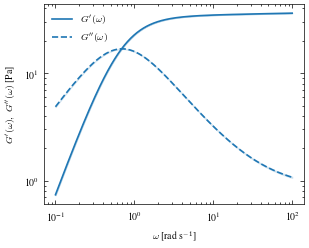

In [8]:
import torch, gpytorch, numpy as np
import matplotlib.pyplot as plt

gp, lik = model.gp_model_, model.likelihood_
phys = gp.phys
dev  = phys.raw_beta.device

y = torch.as_tensor(model.scaler_y_.transform(stress.reshape(-1, 1)).ravel(),
                    dtype=torch.float32, device=dev)
mll = gpytorch.mlls.VariationalELBO(lik, gp, num_data=y.numel())
gp.eval(); lik.eval()
phys._gamma_scale_frozen = phys._feature_stds_frozen = True

# ---- joint Laplace over (beta, tau_c) ----
raw = [phys.raw_beta, phys.raw_tau_c]
for r in raw:
    r.requires_grad_(True)

with gpytorch.settings.cholesky_jitter(1e-6):
    x    = gp.compute_x()
    loss = -mll(gp(x), y) * y.numel()
    g1   = torch.autograd.grad(loss, raw, create_graph=True)
    H    = torch.zeros(2, 2, device=dev)
    for i, gi in enumerate(g1):
        for j, h in enumerate(torch.autograd.grad(gi, raw, retain_graph=True)):
            H[i, j] = h
    # Jacobian d(beta, tau_c)/d(raw) from live property tensors
    Jb = torch.autograd.grad(phys.beta,  raw, retain_graph=True, allow_unused=True)
    Jt = torch.autograd.grad(phys.tau_c, raw, retain_graph=True, allow_unused=True)
    z  = torch.zeros((), device=dev)
    J  = torch.stack([torch.stack([v if v is not None else z for v in Jb]),
                      torch.stack([v if v is not None else z for v in Jt])])

phys._gamma_scale_frozen = phys._feature_stds_frozen = False

H = 0.5 * (H + H.T)
Cov_bt = (J @ torch.linalg.inv(H) @ J.T).detach().cpu().numpy()   # cov(beta, tau_c)

beta = phys.beta.item()
tau  = phys.tau_c.item()
Gc   = model.prefactors_["Gc"]["scalar_mean"]
sd_Gc = (model.prefactors_["Gc"]["scalar_upper"]
         - model.prefactors_["Gc"]["scalar_lower"]) / 3.92

# full 3-parameter covariance; Gc taken independent of the exponents
Cov3 = np.zeros((3, 3))
Cov3[0, 0]   = sd_Gc**2
Cov3[1:, 1:] = Cov_bt
Cov3_t = torch.tensor(Cov3, dtype=torch.float64)

# ---- G*(omega) with bands, by autograd through the analytic FML formula ----
def gstar_torch(Gc_t, b_t, tau_t, w_t):
    wtc    = w_t * tau_t
    cos_1b = torch.cos(torch.pi*(1-b_t)/2)
    denom  = 1 + wtc**(2*(1-b_t)) + 2*wtc**(1-b_t)*cos_1b
    Gp  = Gc_t * wtc**(2-b_t) * torch.cos(torch.pi*b_t/2) / denom
    Gdp = Gc_t * (wtc + wtc**(2-b_t)*torch.sin(torch.pi*b_t/2)) / denom
    return Gp, Gdp

omega  = np.logspace(-1, 2, 300)                 # match your excited band
Gp_m   = np.zeros_like(omega); Gdp_m  = np.zeros_like(omega)
sd_Gp  = np.zeros_like(omega); sd_Gdp = np.zeros_like(omega)
for k, w in enumerate(omega):
    p  = torch.tensor([Gc, beta, tau], dtype=torch.float64, requires_grad=True)
    wt = torch.tensor(w, dtype=torch.float64)
    Gp, Gdp = gstar_torch(p[0], p[1], p[2], wt)
    Gp_m[k], Gdp_m[k] = Gp.item(), Gdp.item()
    gGp,  = torch.autograd.grad(Gp,  p, retain_graph=True)
    gGdp, = torch.autograd.grad(Gdp, p)
    sd_Gp[k]  = torch.sqrt(gGp  @ Cov3_t @ gGp ).item()
    sd_Gdp[k] = torch.sqrt(gGdp @ Cov3_t @ gGdp).item()

# ---- plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6))
ax.plot(omega, Gp_m, "-", color="tab:blue", lw=1.2, label=r"$G'(\omega)$")
ax.fill_between(omega, np.clip(Gp_m-2*sd_Gp, 1e-30, None), Gp_m+2*sd_Gp,
                color="tab:blue", alpha=0.25)
ax.plot(omega, Gdp_m, "--", color="tab:blue", lw=1.2, label=r"$G''(\omega)$")
ax.fill_between(omega, np.clip(Gdp_m-2*sd_Gdp, 1e-30, None), Gdp_m+2*sd_Gdp,
                color="tab:blue", alpha=0.15)

# DFT overlay if you have res:
# ax.plot(res.fft_omega, res.fft_Gp,  "o", color="k", ms=2)
# ax.plot(res.fft_omega, res.fft_Gdp, "o", mfc="none", color="k", ms=2)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\omega$ [rad s$^{-1}$]")
ax.set_ylabel(r"$G'(\omega),\ G''(\omega)$ [Pa]")
ax.legend(frameon=False, fontsize=7)
fig.tight_layout(); plt.show()

In [9]:
import torch, gpytorch, numpy as np
from scipy import stats

gp, lik = model.gp_model_, model.likelihood_
phys = gp.phys
dev  = phys.raw_beta.device

y = torch.as_tensor(model.scaler_y_.transform(stress.reshape(-1, 1)).ravel(),
                    dtype=torch.float32, device=dev)
mll = gpytorch.mlls.VariationalELBO(lik, gp, num_data=y.numel())
gp.eval(); lik.eval()
phys._gamma_scale_frozen = phys._feature_stds_frozen = True

raw = [phys.raw_beta, phys.raw_tau_c]
for r in raw:
    r.requires_grad_(True)

with gpytorch.settings.cholesky_jitter(1e-6):
    x    = gp.compute_x()
    loss = -mll(gp(x), y) * y.numel()

    g1 = torch.autograd.grad(loss, raw, create_graph=True)
    H  = torch.zeros(2, 2, device=dev)
    for i, gi in enumerate(g1):
        for j, h in enumerate(torch.autograd.grad(gi, raw, retain_graph=True)):
            H[i, j] = h

    Jb = torch.autograd.grad(phys.beta,  raw, retain_graph=True, allow_unused=True)
    Jt = torch.autograd.grad(phys.tau_c, raw, retain_graph=True, allow_unused=True)
    z  = torch.zeros((), device=dev)
    J  = torch.stack([torch.stack([v if v is not None else z for v in Jb]),
                      torch.stack([v if v is not None else z for v in Jt])])

phys._gamma_scale_frozen = phys._feature_stds_frozen = False

H = 0.5 * (H + H.T)
Cov_raw = torch.linalg.inv(H).detach().cpu().numpy()          # raw-space cov
Cov     = (J @ torch.linalg.inv(H) @ J.T).detach().cpu().numpy()   # (beta, tau_c) cov

# ---- convergence check (CIs are only valid at a true optimum) ----
grad_vals = [float(v) for v in g1]
print("gradient at optimum:", grad_vals,
      "  <-- both should be ~0" if max(map(abs, grad_vals)) > 0.05 else "  (ok)")

# ---- parameter table ----
names = ["beta", "tau_c"]
vals  = [phys.beta.item(), phys.tau_c.item()]
sd    = np.sqrt(np.diag(Cov))

print(f"\n{'param':8s} {'mean':>10s} {'sd':>9s} {'95% CI':>24s}")
for n, v, s in zip(names, vals, sd):
    print(f"{n:8s} {v:10.4f} {s:9.4f}   [{v-1.96*s:8.4f}, {v+1.96*s:8.4f}]")

# ---- beta vs 0: test in raw (unconstrained) space, boundary-safe ----
rb    = phys.raw_beta.item()
sd_rb = np.sqrt(Cov_raw[0, 0])
sig   = lambda r: 1.0 / (1.0 + np.exp(-r))
ci_beta_raw = (sig(rb - 1.96*sd_rb), sig(rb + 1.96*sd_rb))   # push through sigmoid
z     = rb / sd_rb                        # raw_beta -> -inf as beta -> 0
pval  = 2 * stats.norm.sf(abs(z))
print(f"\nbeta = {vals[0]:.4f}  95% CI [{ci_beta_raw[0]:.4f}, {ci_beta_raw[1]:.4f}] "
      f"(boundary-safe, via raw space)")
print(f"z = {z:.1f},  p = {pval:.1e}  ->  beta is "
      f"{'distinguishable from 0' if ci_beta_raw[0] > 1e-4 else 'NOT distinguishable from 0'}")

gradient at optimum: [-71.19647216796875, -39.104225158691406]   <-- both should be ~0

param          mean        sd                   95% CI
beta         0.0144    0.0001   [  0.0142,   0.0146]
tau_c        1.4866    0.0036   [  1.4797,   1.4936]

beta = 0.0144  95% CI [0.0142, 0.0146] (boundary-safe, via raw space)
z = -556.4,  p = 0.0e+00  ->  beta is distinguishable from 0


/tmp/ipykernel_556021/3735511856.py:41: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  grad_vals = [float(v) for v in g1]


  [Maxwell] step     0 | -ELBO 1.8033 | tau_c=1.003 | wait 0
  [Maxwell] step   200 | -ELBO 0.4197 | tau_c=1.266 | wait 0
  [Maxwell] step   400 | -ELBO -0.0874 | tau_c=1.266 | wait 0
  [Maxwell] step   600 | -ELBO -0.6134 | tau_c=1.266 | wait 0
  [Maxwell] step   800 | -ELBO -1.1342 | tau_c=1.266 | wait 0
  [Maxwell] step  1000 | -ELBO -1.6103 | tau_c=1.266 | wait 0
  [Maxwell] step  1200 | -ELBO -1.9217 | tau_c=1.266 | wait 1
  [Maxwell] step  1400 | -ELBO -2.2422 | tau_c=1.266 | wait 0
  [Maxwell] step  1600 | -ELBO -2.3911 | tau_c=1.267 | wait 0
  [Maxwell] step  1800 | -ELBO -2.4341 | tau_c=1.266 | wait 3
  [Maxwell] step  2000 | -ELBO -2.4312 | tau_c=1.266 | wait 38
  [Maxwell] step  2200 | -ELBO -2.3896 | tau_c=1.266 | wait 42
  [Maxwell] step  2400 | -ELBO -2.4502 | tau_c=1.266 | wait 27
  [Maxwell] step  2600 | -ELBO -2.4503 | tau_c=1.266 | wait 6
  [Maxwell] step  2800 | -ELBO -2.4504 | tau_c=1.266 | wait 150
  [Maxwell] step  3000 | -ELBO -2.4506 | tau_c=1.266 | wait 75
  [M

/scratch/phys/csm/mirandi1/rheogp_v0.3.0_dev_full/rheogp/rheogp/utils.py:275: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); plt.show()


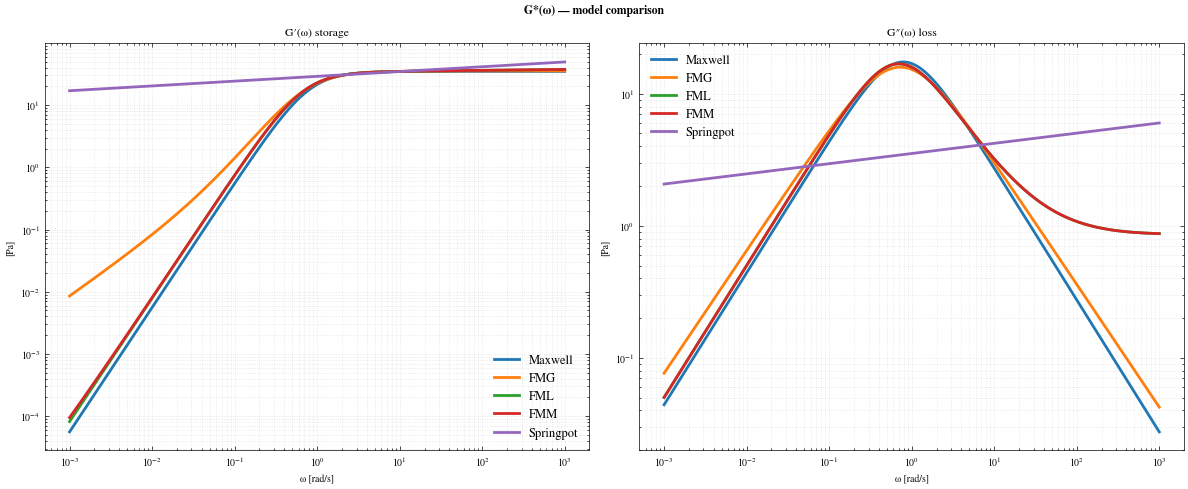

In [10]:
file_path = Path.cwd().parent / "demos" / "data" / "micelles_chirps_short_0.xlsx"
df = pd.read_excel(file_path)

t      = df.iloc[:, 0].values.astype(np.float32)
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32)
# compare models — now ranks by AIC or BIC, your choice
models = {}
for name in ["Maxwell", "FMG", "FML", "FMM", "Springpot"]:
    models[name] = SPGP(model=name, kernel="linear",          # NEW default: two-phase RBF→linear
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000).fit(t, strain, stress)

best = compare_models(models, criterion="bic")   # or criterion="aic"

In [15]:
for name, m in models.items():
    resid = stress - m.pred_
    r2 = 1 - np.sum(resid**2) / np.sum((stress - stress.mean())**2)
    print(f"{name:10s} 1-R2 = {1-r2:.3e}")

Maxwell    1-R2 = 3.419e-04
FMG        1-R2 = 1.660e-04
FML        1-R2 = 4.011e-05
FMM        1-R2 = 4.011e-05
Springpot  1-R2 = 1.118e-02


In [11]:
"""
Residual autocorrelation and information criteria at the effective sample size
=============================================================================
Works directly on a dict of FITTED SPGP objects, as produced by

    models = {}
    for name in ["Maxwell", "FMG", "FML", "FMM", "Springpot"]:
        models[name] = SPGP(...).fit(t, strain, stress)

Reports, for every candidate and both at full N and at the effective
sample size N_eff, the two terms of each criterion separately:

    AIC = 2U + 2k                 BIC = 2U + k ln N
          ^--- fit    ^--- penalty

so that it is visible which term the correlation correction acts on.

USAGE
-----
    import residual_neff as rn
    rows = rn.analyze_models(models, stress, label="wormlike micelles")
    rn.plot_residuals(rows, t)
"""

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------- autocorrelation
def acf(x, nlags=None):
    """Normalized autocorrelation of a 1-D sequence, lags 0..nlags."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = x.size
    if nlags is None:
        nlags = min(n - 1, 5000)
    nfft = 1 << int(np.ceil(np.log2(2 * n)))          # zero-pad: no circular wrap
    f = np.fft.rfft(x, nfft)
    r = np.fft.irfft(f * np.conj(f), nfft)[:nlags + 1].real
    return r / r[0]


def tau_int(rho):
    """
    Integrated autocorrelation time by Geyer's initial-positive-sequence rule:
    accumulate consecutive lag PAIRS while their sum stays positive.

    The pairwise truncation is essential for oscillatory residuals, whose
    raw ACF rings indefinitely; a naive sum would diverge or go negative.
    """
    s, k = 0.0, 1
    while k + 1 < rho.size:
        pair = rho[k] + rho[k + 1]
        if pair <= 0:
            break
        s += pair
        k += 2
    return max(1.0 + 2.0 * s, 1.0), k


# ------------------------------------------------------------- main routine
def analyze_models(models, stress, label="", nlags=5000):
    """
    models : dict {name: fitted SPGP}
    stress : the measured stress array used for training
    """
    stress = np.asarray(stress, float)
    rows = []

    for name, m in models.items():
        resid = stress - np.asarray(m.pred_, float)
        N     = resid.size
        rho   = acf(resid, min(nlags, N - 1))
        tau, kcut = tau_int(rho)
        N_eff = N / tau

        U = m.metrics_["nll"]                       # total negative ELBO
        k = m.metrics_["n_params"]["k_total"]

        # --- full N -------------------------------------------------------
        fit_N      = 2.0 * U
        pen_aic_N  = 2.0 * k
        pen_bic_N  = k * np.log(N)

        # --- effective N --------------------------------------------------
        # U = N*u with u the per-point bound; rescale to U_eff = N_eff*u
        U_eff       = U * (N_eff / N)
        fit_eff     = 2.0 * U_eff
        pen_aic_eff = 2.0 * k                        # AIC penalty is N-free
        pen_bic_eff = k * np.log(N_eff)

        rows.append(dict(
            model=name, N=N, tau=tau, N_eff=N_eff, kcut=kcut, k=k,
            rmse=float(np.sqrt((resid ** 2).mean())),
            fit_N=fit_N, pen_aic_N=pen_aic_N, pen_bic_N=pen_bic_N,
            aic_N=fit_N + pen_aic_N, bic_N=fit_N + pen_bic_N,
            fit_eff=fit_eff, pen_aic_eff=pen_aic_eff, pen_bic_eff=pen_bic_eff,
            aic_eff=fit_eff + pen_aic_eff, bic_eff=fit_eff + pen_bic_eff,
            resid=resid, rho=rho))

    # deltas relative to the best candidate under each criterion
    for key, dkey in (("aic_N", "daic_N"), ("bic_N", "dbic_N"),
                      ("aic_eff", "daic_eff"), ("bic_eff", "dbic_eff")):
        best = min(r[key] for r in rows)
        for r in rows:
            r[dkey] = r[key] - best

    rows.sort(key=lambda r: r["dbic_N"])
    _print_table(rows, label)
    return rows


def _print_table(rows, label):
    print(f"\n=== {label} : autocorrelation and effective sample size ===")
    print(f"{'model':10s} {'N':>7s} {'tau_int':>8s} {'N_eff':>9s} {'k':>3s} "
          f"{'RMSE':>10s}")
    for r in rows:
        print(f"{r['model']:10s} {r['N']:7d} {r['tau']:8.1f} {r['N_eff']:9.1f} "
              f"{r['k']:3d} {r['rmse']:10.4g}")

    print(f"\n--- criterion terms at FULL N ---")
    print(f"{'model':10s} {'2U':>12s} {'2k':>8s} {'k lnN':>9s} "
          f"{'AIC':>12s} {'BIC':>12s} {'dAIC':>9s} {'dBIC':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_N']:12.1f} {r['pen_aic_N']:8.1f} "
              f"{r['pen_bic_N']:9.1f} {r['aic_N']:12.1f} {r['bic_N']:12.1f} "
              f"{r['daic_N']:9.1f} {r['dbic_N']:9.1f}")

    print(f"\n--- criterion terms at EFFECTIVE N ---")
    print(f"{'model':10s} {'2U_eff':>12s} {'2k':>8s} {'k lnNeff':>9s} "
          f"{'AIC_eff':>12s} {'BIC_eff':>12s} {'dAIC_eff':>9s} {'dBIC_eff':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_eff']:12.1f} {r['pen_aic_eff']:8.1f} "
              f"{r['pen_bic_eff']:9.1f} {r['aic_eff']:12.1f} "
              f"{r['bic_eff']:12.1f} {r['daic_eff']:9.1f} {r['dbic_eff']:9.1f}")


# ------------------------------------------------------------------ figure
def plot_residuals(rows, t, which=None):
    """Residual trace and ACF for one model (default: best by BIC at full N)."""
    r = rows[0] if which is None else next(x for x in rows if x["model"] == which)
    t = np.asarray(t, float)

    fig, ax = plt.subplots(1, 2, figsize=(6.2, 2.4))
    ax[0].plot(t, r["resid"], "o", ms=1, alpha=0.5, color="tab:orange",
               rasterized=True)
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_xlabel("$t$ [s]")
    ax[0].set_ylabel(r"$\sigma-\bar{\sigma}$ [Pa]")

    lags = np.arange(r["rho"].size)
    ax[1].plot(lags, r["rho"], "-", color="tab:blue", lw=1.0)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].axvline(r["kcut"], color="k", lw=0.6, ls="--",
                  label=f"truncation lag {r['kcut']}")
    ax[1].set_xlabel("lag [samples]")
    ax[1].set_ylabel(r"$\rho_k$")
    ax[1].set_xlim(0, min(4 * r["kcut"] + 20, r["rho"].size))
    ax[1].legend(frameon=False, fontsize=6)
    for a in ax:
        a.grid(False)
    fig.suptitle(f"{r['model']}:  " r"$\tau_{\rm int}=$" f"{r['tau']:.0f},  "
                 r"$N_{\rm eff}=$" f"{r['N_eff']:.0f}", fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig


=== wormlike micelles : autocorrelation and effective sample size ===
model            N  tau_int     N_eff   k       RMSE
FML           1499     21.9      68.4   7    0.01799
FMM           1499     21.2      70.6   8    0.01799
FMG           1499     51.1      29.3   7     0.0366
Maxwell       1499     55.7      26.9   6    0.05253
Springpot     1499    380.5       3.9   6     0.3003

--- criterion terms at FULL N ---
model                2U       2k     k lnN          AIC          BIC      dAIC      dBIC
FML             -9017.4     14.0      51.2      -9003.4      -8966.2       0.0       0.0
FMM             -9018.2     16.0      58.5      -9002.2      -8959.7       1.2       6.5
FMG             -8058.0     14.0      51.2      -8044.0      -8006.8     959.4     959.4
Maxwell         -7349.9     12.0      43.9      -7337.9      -7306.1    1665.4    1660.1
Springpot       -2453.7     12.0      43.9      -2441.7      -2409.9    6561.6    6556.3

--- criterion terms at EFFECTIVE N ---
mo

/tmp/ipykernel_556021/1213067289.py:164: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


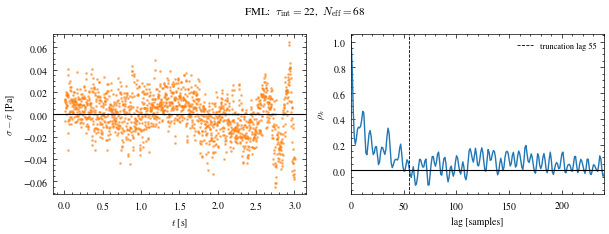

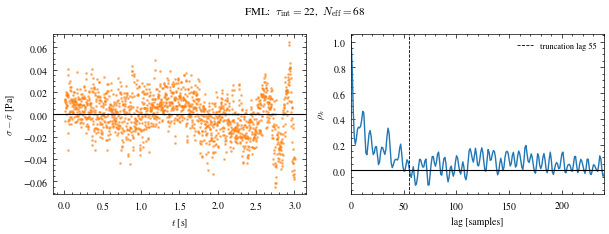

In [12]:
rows = analyze_models(models, stress, label="wormlike micelles")
plot_residuals(rows, t)

In [13]:
n_quiet  = int(1.0 / (t[1] - t[0]))
rho_q    = acf(stress[:n_quiet], nlags=150)
tau_q, _ = tau_int(rho_q)
print(f"instrument noise: tau_int = {tau_q:.2f}")

instrument noise: tau_int = 2.72


In [14]:
r = next(x for x in rows if x["model"] == "FML")
resid = r["resid"]

early, late = t < 2.0, t > 2.5
print("resid  sd early:", resid[early].std(), " late:", resid[late].std())
print("stress sd early:", stress[early].std(), " late:", stress[late].std())
print("ratio  early:", resid[early].std()/stress[early].std(),
      " late:", resid[late].std()/stress[late].std())

resid  sd early: 0.015400480989524342  late: 0.025273957371997887
stress sd early: 2.0759883  late: 3.5067272
ratio  early: 0.007418385278819916  late: 0.0072072778395026625
